## we are going to do a height and weight prediction model 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("SOCR-HeightWeight.csv")
df.head()

,Index,Height(Inches),Weight(Pounds)
0,1,65.78331,112.9925
1,2,71.51521,136.4873
2,3,69.39874,153.0269
3,4,68.21660,142.3354
4,5,67.78781,144.2971


Text(0, 0.5, 'Height')

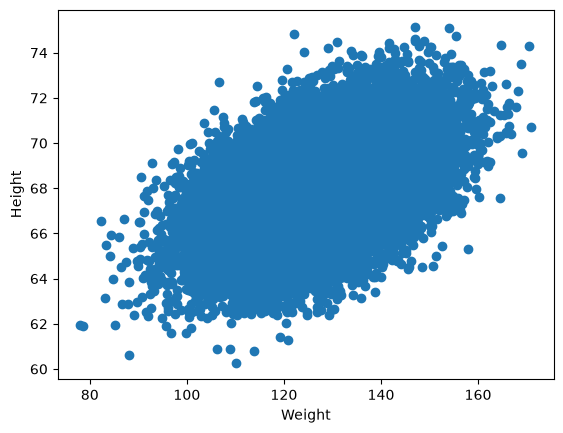

In [3]:
plt.scatter(df['Weight(Pounds)'], df['Height(Inches)'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [4]:
## divide our datasets into independent and dependent features

X = df[['Weight(Pounds)']] #independent features
y = df[['Height(Inches)']] #dependent features

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.20, random_state=42)

In [6]:
X_train.shape, X_test.shape

((20000, 1), (5000, 1))

In [7]:
# standardization the dataset train independent data
# basically applying z score and whatever to bring all features in one perfect scale

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [8]:
x_train = scaler.fit_transform(X_train)

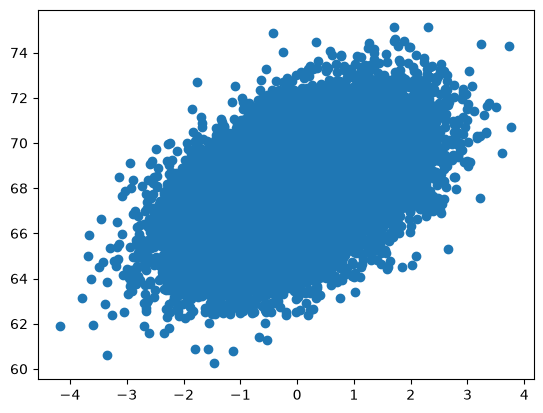

In [9]:
X_test = scaler.transform(X_test)

plt.scatter(x_train, y_train)

In [20]:
## train our simple linear regression model
from sklearn.linear_model import LinearRegression

regression = LinearRegression()

In [25]:
regression.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.95]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[67.99]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[141.42]


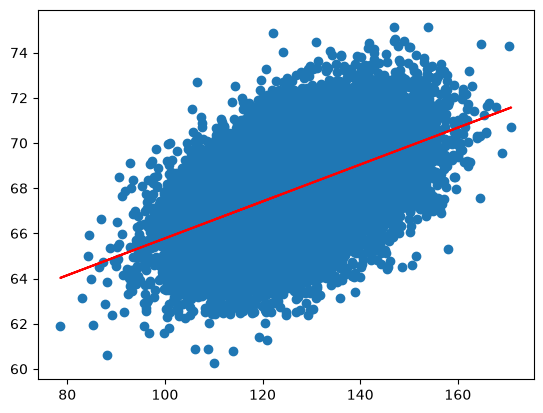

In [15]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(x_train), 'r')

## now prediction of train data:

1 - predicted height output = intercept + coeff_(weights)

2 - y_pred_train = 67.99 + 0.95

## now prediction of test data:

1 - predicted height output = intercept + coef_(weights)

2 - y_pred_test = 67.99 + 0.95

In [17]:
print(regression.coef_)
print(regression.intercept_)

[[0.95022131]]
[67.99034523]


### 2. `y_pred_test` kya hai aur kis liye use ho raha hai?

Isko ek **Student aur Exam** ke real-life example se samjhiye:

| Term | ML me iska matlab | Real-Life Analogy (Exam) |
| :--- | :--- | :--- |
| **`X_train`, `y_train`** | Training Data | Padhai / Syllabus (Questions + Answers) jisse model ne seekha. |
| **`X_test`** | Unseen Test Inputs (Weight) | **Exam ka Question Paper** jo model ke samne pehli baar aaya. |
| **`y_test`** | Actual True Outputs (Height) | **Teacher ki Answer Key** (Asli sach / Ground Truth). |
| **`y_pred_test`** | Model ke Predictions ($\hat{y}$) | **Student ke diye huye Answers**. |

---

####  Kis liye use ho raha hai?

**Reason: Model ka Result (Report Card) nikalne ke liye!**

Model ne naye data par kaisa perform kiya, ye tabhi pata chalega jab hum student ke answers (**`y_pred_test`**) ko teacher ki answer key (**`y_test`**) se compare karenge:

$$\text{Error} = y_{test} - y_{pred\_test}$$

Isi comparison se sir agle cells me **Evaluation Metrics** nikalenge:
1. **MAE (Mean Absolute Error):** On an average model kitne inches ka difference/galti kar raha hai.
2. **MSE / RMSE:** Galti ka squared error.
3. **$R^2$ Score:** Model kitne percent accurate hai (0 to 1 ya 0% to 100%).

Agar hum `y_pred_test` nikalenge hi nahi, to hume pata hi nahi chalega ki hamara model naye data par sahi predict kar raha hai ya kachra result de raha hai!

---

### 💡 Dono ko ache se compare karke dekhne ka code:

Agar aap sirf `y_pred_test, y_test` likhoge to screen par dono lambi messy list ki tarah aayenge. Inko side-by-side compare karne ke liye agle cell me ye likhein:

```python
import pandas as pd

# Actual vs Predicted ko side-by-side dekhne ke liye:
result_df = pd.DataFrame({
    'Actual Height (y_test)': y_test.values.flatten(),
    'Predicted Height (y_pred_test)': y_pred_test.flatten()
})

result_df.head()
```
Isse aapko saaf dikhega ki actual height kitni thi aur model ne kitni predict kari!

In [26]:
y_pred_test = regression.predict(X_test)
y_pred_test,y_test

(array([[68.57909757],
        [66.75591741],
        [68.7180974 ],
        ...,
        [69.14277554],
        [68.19031301],
        [68.61726207]], shape=(5000, 1)),
        Height(Inches)
 6868         68.42447
 24016        67.89663
 9668         67.65922
 13640        69.01299
 14018        69.01055
 ...               ...
 8670         68.93627
 11839        67.28489
 4013         68.57098
 21147        67.09562
 695          70.56979
 
 [5000 rows x 1 columns])

## now we have out Y_test and y_pred_test

### now we gonna test the score with MSE, MAE, RMSE and Rsquare and adjusted rsquare like algos 


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred_test)

mse = mean_squared_error(y_test, y_pred_test)

rmse = np.sqrt(mse)
print(mae)
print(mse)
print(rmse)

1.316304056930067
2.724962846065037
1.6507461482811452


In teen values ka real-life matlab kya hai?
MAE = 1.31 Inches:
Iska matlab hai ki aapka model kisi vyakti ki height predict karte waqt on average sirf ~1.31 inches ki choti si galti kar raha hai (Height ke hisab se ye kaafi kam aur acchi error hai!).

MSE = 2.72 Inches²:
Ye galtiyon ka square kar deta hai taaki badi galtiyon ko zyada penalty mile. Iski unit square ho jati hai ($inches^2$).

RMSE = 1.65 Inches:
MSE ka square root lene par unit wapas normal Inches me aa jati hai. Iska matlab model ki typical galti ~1.65 inches ke aas-paas hai.



In [28]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred_test)
score

0.26055631630450127

In [30]:
# adjusted rsquare

adjusted_r2 = 1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test.shape[1] - 1)
print("Adjusted R2 Score:", adjusted_r2)


Adjusted R2 Score: 0.2604083683885958


In [32]:
# now we have new data point

scaled_weight = scaler.transform([[80]])

scaled_weight

d:\Projects\MachineLearning_Practise\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-4.04716941]])

In [33]:
predicted_height = regression.predict(scaled_weight)
print("Predicted Height:", predicted_height)


Predicted Height: [[64.1446386]]


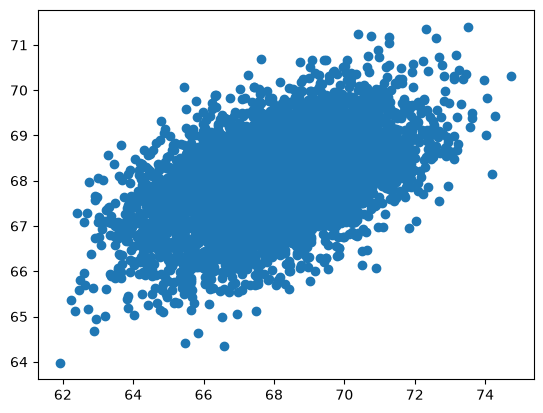

In [34]:
# plotting a catter plot for the prediction

plt.scatter(y_test, y_pred_test)

In [35]:
## residuals 

residuals = y_test - y_pred_test
residuals

,Height(Inches)
6868,-0.154628
24016,1.140713
9668,-1.058877
13640,1.079658
14018,3.217371
...,...
8670,0.046057
11839,1.080896
4013,-0.571796
21147,-1.094693


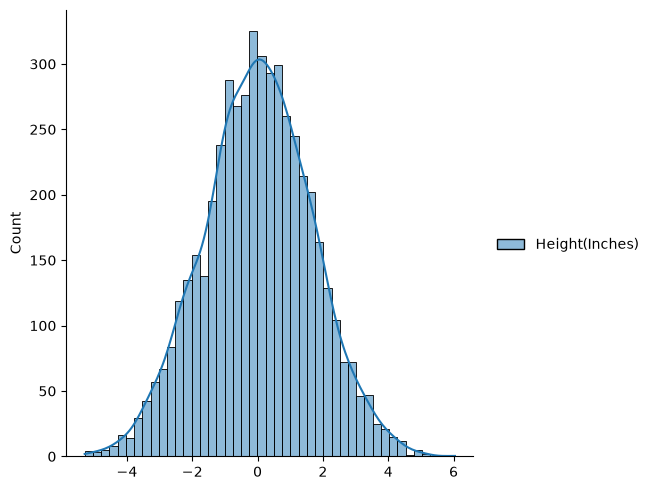

In [41]:
# plotting this residuals

sns.displot(residuals, kde=True)

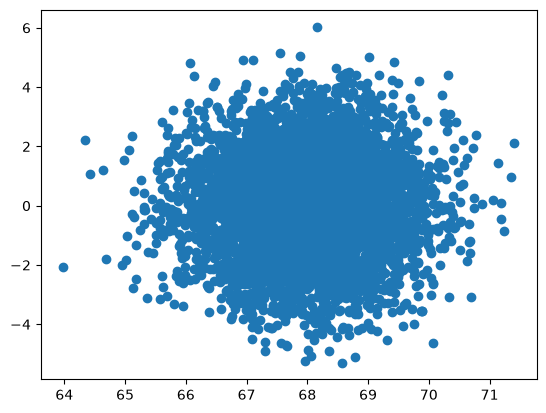

In [42]:
# now if we plot a graph of residuals and predictions

# unifrom distribution

graphofResidualsandPrediction = plt.scatter(y_pred_test, residuals)

graphofResidualsandPrediction